In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
dir = os.getcwd()

ext = ['', '/..', '/../src/models', '/../src/nlp', '/../src/synth']
sys.path += [dir + i for i in ext]

In [2]:
from chat import *
from api.football import *
from scene import Scene

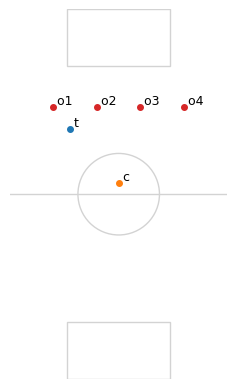

In [3]:
demo1_1 = Scene([
    Teammate('T').at(Vector(-4.5, 6)),
    Coach('C').at(Vector(0, 1)),
    Opponent('O1').at(Vector(-6, 8)),
    Opponent('O2').at(Vector(-2, 8)),
    Opponent('O3').at(Vector(2, 8)),
    Opponent('O4').at(Vector(6, 8)),
])

plotField(demo1_1, axis=False)

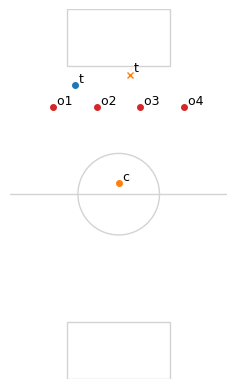

In [4]:
demo1_2 = Scene([
    Teammate('T').at(Vector(-4, 10)),
    Coach('C').at(Vector(0, 1)),
    Target('t').at(Vector(1, 11)),
    Opponent('O1').at(Vector(-6, 8)),
    Opponent('O2').at(Vector(-2, 8)),
    Opponent('O3').at(Vector(2, 8)),
    Opponent('O4').at(Vector(6, 8)),
])

plotField(demo1_2, axis=False)

In [5]:
narration1 = "(a) Wait until your teammate moves past the defending line and pass the ball to him, (b) then move ahead through the defending line to make yourself clear for a pass."

In [6]:
demoMap = {
    '1': {
        'a': demo1_1,
        'b': demo1_2
    }
}

In [7]:
narrations = '\n'.join([f"Demo {i + 1}: {n}" for i, n in enumerate([narration1])])
print(narrations)

Demo 1: (a) Wait until your teammate moves past the defending line and pass the ball to him, (b) then move ahead through the defending line to make yourself clear for a pass.


In [8]:
from interpretable import Interpretable
from task import Task

tasks = Task.fromInterpretable(Interpretable(language=narrations))

for t in tasks:
    print(str(t))

Task ID: 0
Objective (what): Wait until your teammate moves past the defending line and pass the ball to him.
Control (how): Observe your teammate's position and time your pass accurately.
Termination (until): Once the ball is passed to the teammate.
Condition (when): Teammate is in a position past the defending line.
Task ID: 1
Objective (what): Move ahead through the defending line to make yourself clear for a pass.
Control (how): Run into open space beyond the defending line.
Termination (until): Once you are in a clear position to receive a pass.
Condition (when): After passing the ball to your teammate.


In [9]:
from action import *

act = Act()
actions = Action.fromTask(tasks, actionsAPI)
act.do(actions)

In [10]:
actions

In [11]:
for a in act.actions:
    a.learn(demoMap)

{'logic': 'A AND B', 'constraints': [{'id': 'A', 'api': 'AheadOfLine', 'params': {'obj': 'T', 'height': 'midfield'}}, {'id': 'B', 'api': 'HasAngleOfPass', 'params': {'ref': 'T', 'radius': 0.0}}]}
T
T
{'logic': 'A AND B', 'constraints': [{'id': 'A', 'api': 'AheadOfLine', 'params': {'obj': 'C', 'height': 'midfield'}}, {'id': 'B', 'api': 'HasAngleOfPass', 'params': {'ref': 'T', 'radius': None}}]}
T


In [12]:
print(act.export())

{
    "actions": [
        {
            "id": "Idle",
            "args": {
                "precondition": "lambda_precondition"
            },
            "constraints": {
                "lambda_precondition": {
                    "logical": "A AND B",
                    "identifiers": [
                        "A",
                        "B"
                    ],
                    "args": {
                        "A": {
                            "id": "AheadOfLine",
                            "args": {
                                "obj": "T",
                                "height": {
                                    "avg": 6.0,
                                    "std": 0.0
                                }
                            }
                        },
                        "B": {
                            "type": "HasAngleOfPass",
                            "args": {
                                "ref": "T",
                                "rad